# Finance Instruction Dataset Preparation Pipeline

## Objective

This notebook builds a curated finance-oriented instruction dataset for conversational supervised fine-tuning.

The goal is to transform a raw instruction-response dataset into a cleaner training corpus by applying domain filtering, reasoning-quality checks, stratified splitting, and chat-template formatting.

The final output is designed to be directly usable in downstream fine-tuning workflows.

---

## Dataset Source

The dataset is based on the Hugging Face repository `heladell/Finance_DeepSeek-R1-Distill-dataset`.

It contains finance-related instruction-response pairs, including responses with `<think>` reasoning traces generated by a DeepSeek-R1 teacher model.

---

## Preparation Strategy

The preprocessing strategy is designed around four principles:

- domain relevance: keep finance, actuarial, and quantitative reasoning samples
- data quality: remove duplicated, incomplete, or irrelevant examples
- reasoning quality: filter low-quality `<think>` traces when explicit reasoning is present
- training compatibility: format the corpus into a Qwen-compatible conversational SFT structure

---

## Scope

This notebook focuses on dataset preparation only.

Model training, evaluation, deployment, and monitoring are handled in downstream stages.

---

## Output Artifacts

The pipeline exports:

- SFT datasets in JSONL format
- intermediate datasets in Parquet format
- preprocessing reports in CSV format
- visual diagnostics for reporting

---

## Authors

Ashot Akopov  
Henri Bardonnaut  
Tristan Chambert

# 1. Environment Setup

This section initializes the environment and imports the required dependencies.

In [1]:
import re
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 2. Dataset Loading

This section loads the source dataset and converts it into a Pandas DataFrame.

In [2]:
dataset = load_dataset(
    "heladell/Finance_DeepSeek-R1-Distill-dataset",
    split="train"
)

df = dataset.to_pandas()

pipeline_stats = []

pipeline_stats.append({
    "step": "Initial dataset",
    "samples": len(df)
})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26952 [00:00<?, ? examples/s]

# 3. Exploratory Data Analysis

This section performs an initial inspection

## 3.1 Dataset Structure

In [3]:
df.columns

Index(['conversation_id', 'instruction', 'response', 'conversations',
       'gen_input_configs', 'gen_response_configs', 'intent', 'knowledge',
       'difficulty', 'difficulty_generator', 'input_quality',
       'quality_explanation', 'quality_generator', 'task_category',
       'other_task_category', 'task_category_generator', 'language'],
      dtype='object')

In [4]:
df.shape

(26952, 17)

In [5]:
df.columns

df.shape

df = df.drop_duplicates(
    subset=["instruction", "response"]
)

print(f"Remaining samples: {len(df)}")

pipeline_stats.append({
    "step": "Deduplication",
    "samples": len(df)
})

Remaining samples: 23972


## 3.2 Missing Responses

In [6]:
has_response = df["response"].notna().sum()
has_response

np.int64(23971)

In [7]:
df = df[df['response'].notna()]

print(f"Remaining samples: {len(df)}")

pipeline_stats.append({
    "step": "Remove missing responses",
    "samples": len(df)
})

Remaining samples: 23971


## 3.3 Task Categories

In [8]:
per_task = df["task_category"].value_counts().to_frame().reset_index()
per_task

,task_category,count
0,Math,20389
1,Data analysis,1040
2,Information seeking,996
3,Reasoning,606
4,Planning,444
5,Coding & Debugging,390
6,Advice seeking,64
7,Editing,30
8,Brainstorming,7
9,Role playing,1


In [9]:
excluded_categories = (
    "Coding & Debugging",
    "Advice seeking",
    "Editing",
    "Brainstorming",
    "Role playing",
    "Creative writing"
)

df = df[~df["task_category"].isin(excluded_categories)]

print(f"Remaining samples: {len(df)}")

pipeline_stats.append({
    "step": "Relevant category filtering",
    "samples": len(df)
})

Remaining samples: 23478


## 3.4 Language Filtering

In [10]:
per_lan = df["language"].value_counts().to_frame().reset_index()
per_lan

,language,count
0,EN,23219
1,LA,173
2,AZ,20
3,DA,18
4,DE,7
5,RO,7
6,CA,4
7,ST,4
8,EO,4
9,YO,4


In [11]:
df = df[df["language"] == "EN"]

print(f"Remaining samples: {len(df)}")

pipeline_stats.append({
    "step": "English-only filtering",
    "samples": len(df)
})

Remaining samples: 23219


# 4. Financial Domain Filtering

This section keeps samples that are relevant to finance using simple, auditable heuristics.

## 4.1 Finance-Related Keyword Filtering

The filtering step relies on finance-related keywords covering corporate finance, financial markets, banking, insurance, accounting, macroeconomics, and actuarial science.

This keyword-based filter is intentionally simple, interpretable, and auditable.

It is used as a conservative preprocessing step rather than as a semantic classifier, and may still produce false positives or false negatives.

In [12]:
def is_finance_related(row):

    finance_keywords = [

        # Corporate finance
        "ebitda",
        "cash flow",
        "free cash flow",
        "fcf",
        "capex",
        "valuation",
        "revenue",
        "profit",
        "margin",
        "dividend",

        # Financial markets
        "bond",
        "equity",
        "stock",
        "portfolio",
        "asset",
        "liability",
        "yield",
        "volatility",
        "option",
        "derivative",
        "credit",
        "interest rate",
        "inflation",
        "market risk",

        # Banking and insurance
        "loan",
        "mortgage",
        "insurance",
        "solvency",
        "scr",
        "actuarial",
        "taeg",

        # Accounting and financial analysis
        "balance sheet",
        "income statement",
        "financial statement",
        "return on equity",
        "roe",
        "roa",

        # Macroeconomics
        "gdp",
        "federal reserve",
        "fed",
        "central bank",
        "monetary policy"
    ]

    text = (
        str(row["instruction"]) + " " +
        str(row["response"]) + " " +
        str(row.get("intent", "")) + " " +
        str(row.get("knowledge", ""))
    ).lower()

    return any(
        keyword in text
        for keyword in finance_keywords
    )

df["finance_related"] = df.apply(
    is_finance_related,
    axis=1
)


## 4.2 Filtering Diagnostics

The cross-tabulation below checks how finance-related samples are distributed across task categories.

In [13]:
finance_filtering_table = pd.crosstab(
    df["task_category"],
    df["finance_related"],
    margins=True
)

finance_filtering_table

finance_related,False,True,All
task_category,,,
Data analysis,114,925,1039
Information seeking,162,826,988
Math,5529,14611,20140
Planning,48,395,443
Reasoning,109,497,606
All,5962,17254,23216


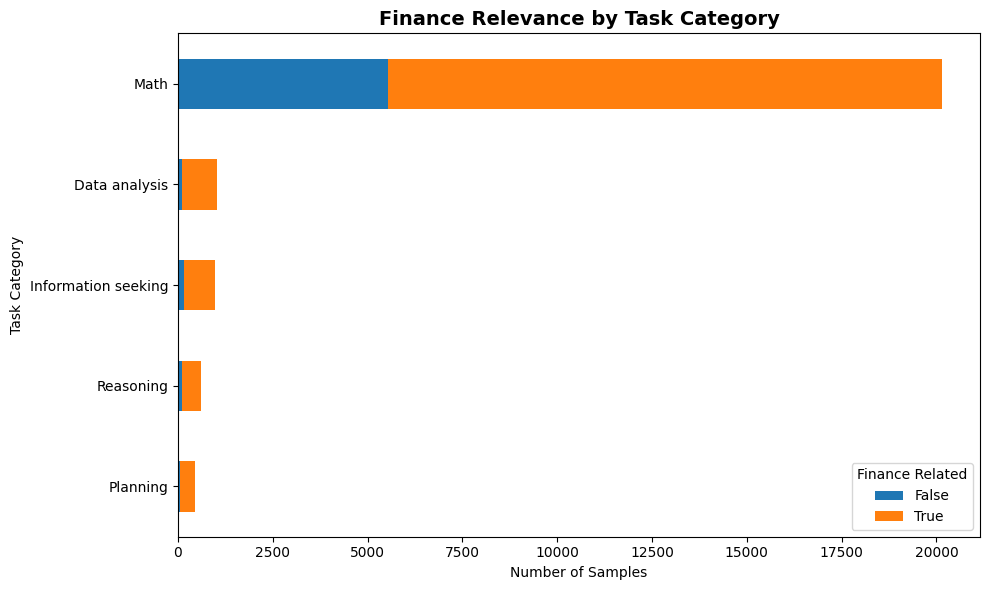

In [14]:
finance_counts = (
    df.groupby(["task_category", "finance_related"])
    .size()
    .unstack(fill_value=0)
    .sort_values(by=True, ascending=True)
)

ax = finance_counts.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Finance Relevance by Task Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Samples")
ax.set_ylabel("Task Category")
ax.legend(title="Finance Related")

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("finance_filtering_distribution.png", bbox_inches="tight", dpi=300)

## 4.3 Domain Filtering

Samples unrelated to finance are removed.

`Math` samples are preserved because they remain useful for numerical and symbolic reasoning.

In [15]:
df = df[
    (df["task_category"] == "Math")
    |
    (df["finance_related"])
]

print(f"Remaining samples: {len(df)}")

pipeline_stats.append({
    "step": "Finance filtering",
    "samples": len(df)
})

Remaining samples: 22786


# 5. Reasoning Quality Filtering

This section detects explicit reasoning traces and filters low-quality reasoning examples.

## 5.1 Reasoning Trace Detection


In [16]:
def has_think(response):

    if response is None:
        return False

    return bool(
        re.search(
            r"<think>.*?</think>",
            str(response),
            flags=re.DOTALL
        )
    )


df["has_think"] = df["response"].apply(has_think)

df["has_think"].value_counts().to_frame().reset_index()

,has_think,count
0,True,17038
1,False,5748


## 5.2 Reasoning Quality Assessment

A lightweight heuristic filter is applied to remove reasoning traces that are too short, too noisy, poorly structured, or missing a usable final answer.

In [17]:
# Extract reasoning traces enclosed within <think> tags

def extract_think(response):
    """
    Extract reasoning content from <think> tags.
    """
    match = re.search(
        r"<think>(.*?)</think>",
        str(response),
        flags=re.DOTALL
    )
    return match.group(1).strip() if match else ""


# Remove reasoning traces and preserve the final answer

def remove_think(response):
    """
    Remove <think> blocks from the response.
    """
    return re.sub(
        r"<think>.*?</think>",
        "",
        str(response),
        flags=re.DOTALL
    ).strip()


# Evaluate reasoning trace quality for training

def is_good_reasoning(row):
    """
    Evaluate whether a reasoning trace is suitable for training.
    """

    instruction = str(row["instruction"])
    response = str(row["response"])

    think = extract_think(response)
    final_answer = remove_think(response)

    instruction_words = len(instruction.split())
    think_words = len(think.split())
    final_answer_words = len(final_answer.split())

    # Avoid division by zero
    think_instruction_ratio = think_words / max(instruction_words, 1)

    noise_words = [
        "wait",
        "maybe",
        "hmm",
        "perhaps",
        "let me think",
        "actually"
    ]

    noise_score = sum(
        think.lower().count(word)
        for word in noise_words
    )

    has_structure = any(
        marker in think.lower()
        for marker in [
            "first",
            "then",
            "finally",
            "therefore",
            "step",
            "1.",
            "2.",
            "so,"
        ]
    )

    has_formula = any(
        symbol in think
        for symbol in ["=", "+", "-", "/", "*", "%"]
    )

    has_final_answer = final_answer_words > 20

    if think_words == 0:
        return False

    if think_words < 60:
        return False

    if not has_final_answer:
        return False

    if noise_score > 12:
        return False

    if think_instruction_ratio > 20:
        return False

    if think_instruction_ratio <= 4:
        return noise_score <= 8

    if 4 < think_instruction_ratio <= 10:
        return (
            noise_score <= 5
            and (has_structure or has_formula)
        )

    if 10 < think_instruction_ratio <= 20:
        return (
            noise_score <= 2
            and has_structure
            and has_formula
        )

    return False

In [18]:
df["good_reasoning"] = df.apply(
    is_good_reasoning,
    axis=1
)

In [19]:
reasoning_quality_table = pd.crosstab(
    df["has_think"],
    df["good_reasoning"],
    margins=True
)

reasoning_quality_table

good_reasoning,False,True,All
has_think,,,
False,5748,0,5748
True,8999,8039,17038
All,14747,8039,22786


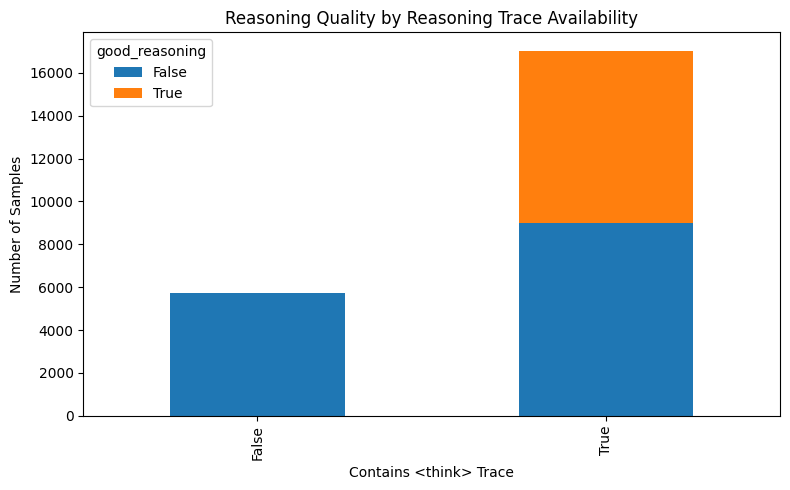

In [20]:

reasoning_quality_matrix = reasoning_quality_table.iloc[:-1, :-1]

ax = reasoning_quality_matrix.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("Reasoning Quality by Reasoning Trace Availability")
ax.set_xlabel("Contains <think> Trace")
ax.set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("reasoning_quality_distribution.png", bbox_inches="tight")

## 5.3 Qualitative Validation

A manual inspection is performed on both high-quality and low-quality reasoning samples.

In [21]:
good_examples = df[
    df["good_reasoning"]
]

good_examples.sample(5)[
    ["instruction", "response"]
]

,instruction,response
5954,If the profit on a shirt is 10% of the cost pr...,"<think>\nFirst, I need to determine the sellin..."
309,"In a company, the production cost for an item ...","<think>\nFirst, I need to determine the curren..."
13070,"The Johnsons have $1,500 in a savings account ...","<think>\nFirst, I need to identify the princip..."
14472,"Here's a list of 15 stocks, their PEG ratios, ...","<think>\nAlright, let's tackle this problem st..."
13818,### Pricing Incentives for Green Building Cert...,"<think>\nFirst, I need to determine the final ..."


In [22]:
bad_examples = df[
    (df["has_think"])
    & (~df["good_reasoning"])
]

bad_examples.sample(5)[
    ["instruction", "response"]
]

,instruction,response
5166,"In the Standard Model of particle physics, the...","<think>\nOkay, so I'm trying to understand the..."
9818,Let \(K\) be a finite Galois extention of \(F\...,"<think>\nOkay, so I have this problem about Ga..."
22892,"In this problem, we'll focus on characterizing...","<think>\nOkay, so I have this problem about Be..."
17507,If a square matrix has a pair of complex conju...,"<think>\nOkay, so I have this question: If a s..."
9956,The co-op stores intend to operate 200 branche...,"<think>\nOkay, so I need to design an optimiza..."


Samples without explicit reasoning are preserved. Samples containing `<think>` traces are kept only when the reasoning-quality heuristic validates them.

In [23]:
# Extract final answer without <think> blocks
df["final_answer"] = df["response"].apply(remove_think)

# Reasoning trace extracted separately
df["think"] = df["response"].apply(extract_think)


def is_good_answer(row):
    """
    Heuristic filter to estimate whether the final answer is usable.

    Important:
    - This does not prove the answer is perfectly correct.
    - It removes answers that are clearly too short, empty, repetitive,
      noisy, or structurally weak.
    """

    instruction = str(row["instruction"])
    answer = str(row["final_answer"])

    answer_words = answer.split()
    answer_len = len(answer_words)

    # Empty or very short answers are usually not useful for SFT
    if answer_len < 20:
        return False

    # Very long answers are suspicious and inefficient
    if answer_len > 900:
        return False

    # Detect strong repetition
    unique_ratio = len(set(w.lower() for w in answer_words)) / max(answer_len, 1)
    if unique_ratio < 0.35:
        return False

    # Detect generic or noisy model phrases
    noisy_patterns = [
        "i cannot",
        "i'm unable",
        "as an ai",
        "i do not have access",
        "i don't have access",
        "let me think",
        "wait",
        "actually",
        "maybe",
        "perhaps",
    ]

    noisy_count = sum(
        pattern in answer.lower()
        for pattern in noisy_patterns
    )

    if noisy_count >= 2:
        return False

    # Minimal overlap between question and answer
    instruction_words = {
        w.lower()
        for w in instruction.split()
        if len(w) > 4
    }

    answer_words_set = {
        w.lower()
        for w in answer.split()
        if len(w) > 4
    }

    overlap = len(instruction_words & answer_words_set)

    if overlap == 0 and len(instruction_words) > 0:
        return False

    return True


df["good_answer"] = df.apply(is_good_answer, axis=1)

In [24]:
def decide_sample_type(row):
    """
    Decide how each sample should be used.

    Rules:
    - bad answer -> remove full row
    - good answer + good CoT -> keep CoT + answer
    - good answer + bad CoT -> keep answer only
    - good answer + no CoT -> keep answer only
    """

    if not row["good_answer"]:
        return "drop"

    if row["has_think"] and row["good_reasoning"]:
        return "cot"

    return "answer_only"


df["sample_type"] = df.apply(decide_sample_type, axis=1)

df["sample_type"].value_counts()

,count
sample_type,
answer_only,8533
cot,7815
drop,6438


In [25]:
df = df[df["sample_type"] != "drop"].copy()

print(f"Remaining samples after answer and reasoning filtering: {len(df)}")

pipeline_stats.append({
    "step": "Answer and reasoning quality filtering",
    "samples": len(df)
})

Remaining samples after answer and reasoning filtering: 16348


# 6. Final Dataset Construction

This section prepares the cleaned dataset, train/test split, conversational format, and exports.

In [26]:
df_filtered = df.copy()

In [27]:
# Build preprocessing statistics summary

stats_df = pd.DataFrame(pipeline_stats)

# Retention rate relative to the initial dataset
stats_df["retention_rate"] = (
    100 * stats_df["samples"]
    / stats_df["samples"].iloc[0]
).round(2)

# Number of removed samples at each step
stats_df["removed_samples"] = (
    stats_df["samples"].shift(1) - stats_df["samples"]
).fillna(0).astype(int)

# Retention rate relative to the previous preprocessing step
stats_df["step_retention_rate"] = (
    100 * stats_df["samples"]
    / stats_df["samples"].shift(1)
).fillna(100).round(2)

stats_df

,step,samples,retention_rate,removed_samples,step_retention_rate
0,Initial dataset,26952,100.00,0,100.00
1,Deduplication,23972,88.94,2980,88.94
2,Remove missing responses,23971,88.94,1,100.00
3,Relevant category filtering,23478,87.11,493,97.94
4,English-only filtering,23219,86.15,259,98.90
5,Finance filtering,22786,84.54,433,98.14
6,Answer and reasoning quality filtering,16348,60.66,6438,71.75


# 6.1 Clean Dataset Assembly

Only the columns required for analysis, quality checks, and training preparation are preserved.

In [28]:
# Columns preserved for analysis and training preparation

clean_columns = [
    "instruction",
    "response",
    "final_answer",
    "think",
    "task_category",
    "difficulty",
    "input_quality",
    "has_think",
    "finance_related",
    "good_reasoning",
    "good_answer",
    "sample_type"
]

df_clean = df_filtered[clean_columns].copy()

In [29]:
def clean_difficulty(x):
    if x == "very easy":
        return "easy"
    if x == "very hard":
        return "hard"
    return x

df_clean["difficulty_clean"] = df_clean["difficulty"].apply(clean_difficulty)

## 6.2 Preprocessing Report and Visual Diagnostics

This section summarizes the evolution of the dataset across preprocessing steps and provides visual diagnostics for the final curated dataset.

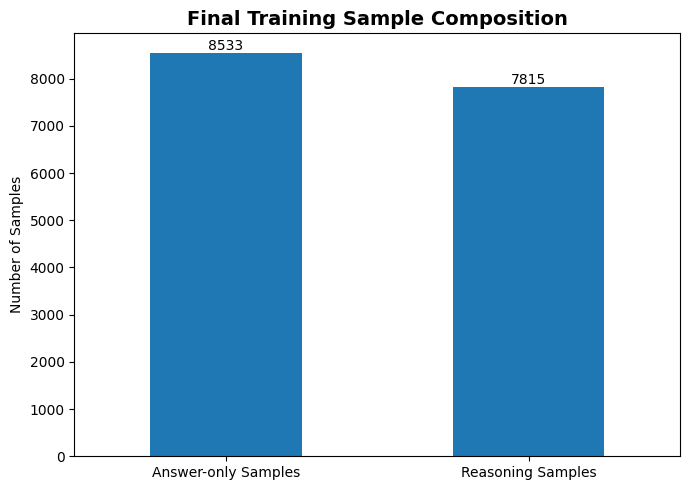

In [30]:
reasoning_counts = (
    df_clean["sample_type"]
    .value_counts()
    .rename({
        "cot": "Reasoning Samples",
        "answer_only": "Answer-only Samples"
    })
)

ax = reasoning_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title(
    "Final Training Sample Composition",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Number of Samples")

ax.bar_label(ax.containers[0])

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

fig = ax.get_figure()

fig.savefig(
    "final_reasoning_distribution.png",
    bbox_inches="tight",
    dpi=300
)

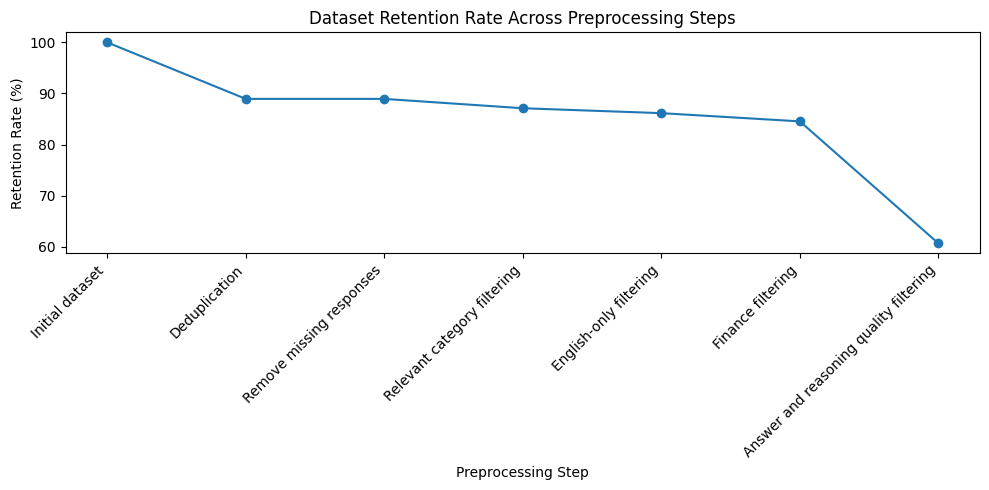

In [31]:

ax = stats_df.plot(
    x="step",
    y="retention_rate",
    kind="line",
    marker="o",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Dataset Retention Rate Across Preprocessing Steps")
ax.set_xlabel("Preprocessing Step")
ax.set_ylabel("Retention Rate (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("dataset_retention_rate.png", bbox_inches="tight")

## 6.3 Train/Test Split

In [33]:
# Separate reasoning and answer-only samples

df_cot = df_clean[
    df_clean["sample_type"] == "cot"
].copy()

df_answer_only = df_clean[
    df_clean["sample_type"] == "answer_only"
].copy()

# ---------------------------------------------------
# Safety cleaning for difficulty labels
# ---------------------------------------------------

df_cot["difficulty_clean"] = (
    df_cot["difficulty_clean"]
    .fillna("unknown")
    .astype(str)
)

df_answer_only["difficulty_clean"] = (
    df_answer_only["difficulty_clean"]
    .fillna("unknown")
    .astype(str)
)

# ---------------------------------------------------
# Goal:
# - ALL validated CoT samples go to train
# - test contains ONLY answer-only samples
# - test preserves difficulty distribution as much as possible
# - global split is exactly 90/10 when enough answer-only samples exist
# ---------------------------------------------------

total_samples = len(df_clean)
target_test_size = round(total_samples * 0.10)

if target_test_size <= 0:
    raise ValueError("The cleaned dataset is too small to create a 90/10 split.")

if len(df_answer_only) < target_test_size:
    raise ValueError(
        "Not enough answer-only samples to build a 10% test set without CoT. "
        f"Required: {target_test_size}, available: {len(df_answer_only)}."
    )

# ---------------------------------------------------
# Stratified split ONLY on answer-only samples
# ---------------------------------------------------

difficulty_counts = df_answer_only["difficulty_clean"].value_counts()

can_stratify = (
    difficulty_counts.min() >= 2
    and target_test_size >= df_answer_only["difficulty_clean"].nunique()
)

if can_stratify:
    _, df_test = train_test_split(
        df_answer_only,
        test_size=target_test_size,
        random_state=42,
        stratify=df_answer_only["difficulty_clean"]
    )
else:
    df_test = df_answer_only.sample(
        n=target_test_size,
        random_state=42
    )

# ---------------------------------------------------
# Remaining answer-only samples go to training
# ---------------------------------------------------

remaining_answer_only = df_answer_only.drop(df_test.index)

# ---------------------------------------------------
# Final training set
# ---------------------------------------------------

df_train = pd.concat(
    [
        df_cot,
        remaining_answer_only
    ],
    axis=0
)

df_train = df_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_test = df_test.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# ---------------------------------------------------
# Diagnostics
# ---------------------------------------------------

print(f"Total samples: {total_samples}")
print(f"Train samples: {len(df_train)} ({len(df_train) / total_samples:.1%})")
print(f"Test samples: {len(df_test)} ({len(df_test) / total_samples:.1%})")

print("\nTrain sample types:")
print(df_train["sample_type"].value_counts())

print("\nTest sample types:")
print(df_test["sample_type"].value_counts())

print("\nTrain difficulty distribution:")
print(
    df_train["difficulty_clean"]
    .value_counts(normalize=True)
    .round(3)
)

print("\nTest difficulty distribution:")
print(
    df_test["difficulty_clean"]
    .value_counts(normalize=True)
    .round(3)
)

Total samples: 16348
Train samples: 14713 (90.0%)
Test samples: 1635 (10.0%)

Train sample types:
sample_type
cot            7815
answer_only    6898
Name: count, dtype: int64

Test sample types:
sample_type
answer_only    1635
Name: count, dtype: int64

Train difficulty distribution:
difficulty_clean
medium     0.587
easy       0.389
hard       0.024
unknown    0.001
Name: proportion, dtype: float64

Test difficulty distribution:
difficulty_clean
medium     0.629
easy       0.329
hard       0.042
unknown    0.001
Name: proportion, dtype: float64


The split intentionally sends all validated CoT samples to the training set. The test set contains only answer-only samples and is sampled to preserve the difficulty distribution as much as possible.


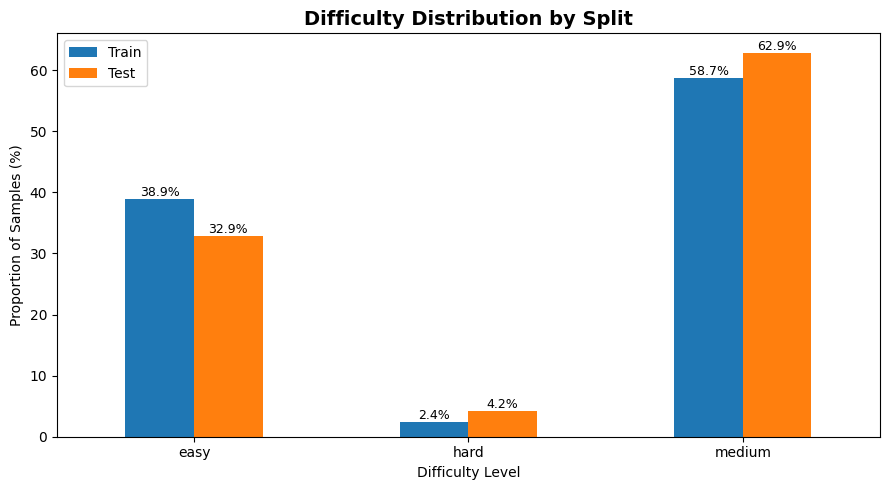

In [ ]:
difficulty_order = ["easy", "medium", "hard"]

split_difficulty = pd.DataFrame({
    "Train": df_train["difficulty_clean"].value_counts(normalize=True),
    "Test": df_test["difficulty_clean"].value_counts(normalize=True)
}).reindex(difficulty_order).fillna(0) * 100

ax = split_difficulty.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title(
    "Difficulty Distribution by Split",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Difficulty Level")
ax.set_ylabel("Proportion of Samples (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9
    )

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

fig = ax.get_figure()

fig.savefig(
    "split_difficulty_distribution.png",
    bbox_inches="tight",
    dpi=300
)

## 6.4 Conversational Formatting

The dataset is converted into a Qwen-compatible conversational format while preserving both reasoning-heavy and concise response examples.

In [35]:
def build_completion(row):
    """
    Build the assistant response used for supervised fine-tuning.

    - cot samples keep the validated reasoning trace and the final answer.
    - answer_only samples keep only the final answer.
    """

    answer = str(row["final_answer"]).strip()

    if row["sample_type"] == "cot":
        think = str(row["think"]).strip()

        return f"""<think>
{think}
</think>

{answer}"""

    return answer


def format_prompt(row):
    """
    Qwen-compatible conversational SFT format.
    """

    completion = build_completion(row)

    return f"""<|im_start|>system
You are an expert assistant in quantitative finance, actuarial science, and financial risk analysis.

Provide accurate, concise, and well-structured answers.

When solving quantitative problems, clearly state assumptions, formulas, and calculations when relevant.
<|im_end|>

<|im_start|>user
{row["instruction"]}
<|im_end|>

<|im_start|>assistant
{completion}
<|im_end|>
"""


# Apply conversational formatting to train and test subsets

df_train["text"] = df_train.apply(format_prompt, axis=1)
df_test["text"] = df_test.apply(format_prompt, axis=1)

# Keep metadata useful for training diagnostics and downstream benchmark generation

sft_columns = [
    "text",
    "instruction",
    "final_answer",
    "think",
    "sample_type",
    "difficulty_clean"
]

train_sft = df_train[sft_columns].copy()
test_sft = df_test[sft_columns].copy()

print("Train SFT sample types:")
print(train_sft["sample_type"].value_counts())

print("\nTest SFT sample types:")
print(test_sft["sample_type"].value_counts())


Train SFT sample types:
sample_type
cot            7815
answer_only    6898
Name: count, dtype: int64

Test SFT sample types:
sample_type
answer_only    1635
Name: count, dtype: int64


## 6.5 Dataset Card Summary

- Source: `heladell/Finance_DeepSeek-R1-Distill-dataset`
- Language: English
- Domain: finance, actuarial science, and quantitative reasoning
- Training format: Qwen-compatible conversational SFT format
- Split strategy: custom 90/10 split
  - all validated CoT samples are assigned to train
  - test contains only answer-only samples
  - difficulty distribution is preserved in the answer-only test sample when possible
- Main filtering criteria:
  - task category
  - language
  - finance relevance
  - answer-quality heuristics
  - reasoning-quality heuristics
- Known limitations:
  - keyword-based finance filtering
  - heuristic answer and reasoning quality checks
  - possible teacher-model bias inherited from distilled responses
- Training objective: conversational supervised fine-tuning
- Exported datasets:
  - JSONL files for downstream fine-tuning
  - Parquet files for inspection and reproducibility
- Visual diagnostics:
  - `dataset_retention_rate.png`
  - `finance_filtering_distribution.png`
  - `reasoning_quality_distribution.png`
  - `final_reasoning_distribution.png`
  - `split_difficulty_distribution.png`
- Reporting artifacts:
  - `preprocessing_report.csv`
  - `finance_filtering_table.csv`
  - `reasoning_quality_table.csv`


## 6.6 Dataset Export

The `.jsonl` files are used for downstream fine-tuning pipelines.

The `.parquet` files are preserved for reproducibility, inspection, and reporting.

In [36]:
# Export SFT datasets in JSONL format

train_sft.to_json(
    "train_sft.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

test_sft.to_json(
    "test_sft.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)


In [37]:
# Export intermediate datasets in Parquet format

df_filtered.to_parquet(
    "df_filtered.parquet",
    index=False
)

df_clean.to_parquet(
    "df_clean.parquet",
    index=False
)

df_train.to_parquet(
    "df_train.parquet",
    index=False
)

df_test.to_parquet(
    "df_test.parquet",
    index=False
)

print("Datasets successfully exported.")

Datasets successfully exported.


In [38]:
# Reporting
stats_df.to_csv("preprocessing_report.csv", index=False)
finance_filtering_table.to_csv("finance_filtering_table.csv")
reasoning_quality_table.to_csv("reasoning_quality_table.csv")

In [39]:
from google.colab import files

# Download exported datasets and intermediate artifacts

files.download("train_sft.jsonl")
files.download("test_sft.jsonl")

files.download("df_filtered.parquet")
files.download("df_clean.parquet")
files.download("df_train.parquet")
files.download("df_test.parquet")

# Reporting
files.download("dataset_retention_rate.png")
files.download("finance_filtering_distribution.png")
files.download("reasoning_quality_distribution.png")
files.download("final_reasoning_distribution.png")
files.download("split_difficulty_distribution.png")
files.download("preprocessing_report.csv")
files.download("finance_filtering_table.csv")
files.download("reasoning_quality_table.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 7. Conclusion

This notebook implemented a complete data preparation pipeline for a finance-oriented conversational training dataset.

The workflow combined:
- exploratory diagnostics
- domain-specific filtering
- reasoning-quality filtering
- stratified train/test splitting
- conversational formatting
- dataset export preparation

The final dataset is structured for downstream supervised fine-tuning workflows while preserving both concise responses and higher-quality reasoning examples.

## Next Steps

The next stages of the project include:
- fine-tuning the target model using the exported SFT datasets
- evaluating performance on finance and quantitative reasoning tasks
- comparing outputs against the base model
- assessing hallucination rate, reasoning quality, and response consistency

# 8. Limitations and Future Improvements

Current limitations include:
- keyword-based finance filtering
- heuristic reasoning-quality evaluation
- potential teacher-model bias
- absence of semantic relevance scoring
- no human annotation was used to validate the full dataset

Possible improvements:
- embedding-based semantic filtering
- toxicity and hallucination filtering
- perplexity-based quality scoring
- automatic duplicate detection using embeddings
- human evaluation of reasoning quality